<!--
Copyright (c) 2020-2024 Key4hep-Project.

Licensed under the Apache License, Version 2.0.
-->

# Hands-on 6: reading EDM4hep hits and contributions

This is the completed version of `readEdm4hep.ipynb`. It reads the **simplecalo2** EDM4hep file in Python and builds the total energy spectrum, longitudinal shower profile, lateral shower shape, and contribution timing distribution.

Uproot reads the events, DD4hep decodes cell IDs, and Awkward Array, NumPy, and Matplotlib handle the analysis and plots. No ROOT histograms, canvases, or output files are used.

In [1]:
import awkward as ak
import dd4hep
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import uproot

from drdcalo_tutorials import simplecalo2_input

## Open the event data

The generated 500-event file is used when available; otherwise the notebook uses the bundled 10-event sample. Set `SIMPLECALO2_FILE` to choose another compatible file.

In [2]:
input_file = simplecalo2_input()

events = uproot.open(input_file, handler=uproot.MultithreadedFileSource)["events"]
print(f"Reading {events.num_entries} events from {input_file}")

Reading 10 events from /home/j/jbeirer/BNLSchoolTest/SoftwareTutorials/DD4hepTutorials/data/simplecalo2_sample.root


## Q1 — decode the cell ID

Each hit carries a 64-bit `cellID`. The encoding string in `simplecalo2/compact/simplecalo2.xml` gives each field's width, from least to most significant bits. DD4hep's native bit-field decoder interprets it for us.

In [3]:
# Q1: the <id> element of the <readout> block in simplecalo2.xml
ENCODING = "calolayer:5,abslayer:1,cellid:10"
decoder = dd4hep.core.DDSegmentation.BitFieldCoder(ENCODING)
print("fields:", [field.name() for field in decoder.fields()])

fields: ['calolayer', 'abslayer', 'cellid']


## Q2 and Q3 — read and decode the hits

Uproot exposes each EDM4hep member as an Awkward array with one nested list per event. The hit collection is named after the detector readout. The `decode` helper turns DD4hep's knowledge of the bit layout into a NumPy shift-and-mask, so the whole array is decoded in one operation.

In [4]:
# Q2: the collection is named after the readout in the compact file
COLLECTION = "simplecaloRO"

def read(field, collection=COLLECTION):
    return events[f"{collection}/{collection}.{field}"].array(library="ak")

cell_ids = read("cellID")
hit_energies = read("energy")
hit_x = read("position.x")
hit_y = read("position.y")

# Q3: decode the flattened cell IDs
# The decoder knows where each field sits inside the 64-bit cellID. Applying that
# shift and mask with NumPy decodes the whole array at once, which is what keeps
# this cell fast once you point the notebook at a full 500-event simulation.
def decode(field, ids):
    element = decoder[field]
    values = (ids >> element.offset()) & ((1 << element.width()) - 1)
    if element.isSigned():  # simplecalo1 encodes x and y as signed fields
        sign_bit = 1 << (element.width() - 1)
        values = (values ^ sign_bit) - sign_bit
    return values

flat_cell_ids = ak.to_numpy(ak.flatten(cell_ids))
calo_layer = decode("calolayer", flat_cell_ids)
abs_layer = decode("abslayer", flat_cell_ids)
sub_cell_id = decode("cellid", flat_cell_ids)

N_LAYERS = 20  # LayersNumber in simplecalo2.xml
N_CELLS = 10   # SensLayerX / CellX
cell_x = sub_cell_id % N_CELLS
cell_y = sub_cell_id // N_CELLS
print(f"Read {ak.sum(ak.num(hit_energies))} hits")

Read 446 hits


## Q4 — total energy and longitudinal profile

Summing on `axis=1` keeps the event boundary and gives one total per event. Flattening removes that boundary so the hits can be histogrammed by layer. As in the original analysis, the layer histogram is divided by the number of events.

In [5]:
# Q4
n_events = events.num_entries
total_energies = ak.to_numpy(ak.sum(hit_energies, axis=1))
energy = ak.to_numpy(ak.flatten(hit_energies)).astype(float)
layer = calo_layer

energy_max = 1.2 * total_energies.max() if total_energies.max() > 0 else 1.0
energy_counts, energy_edges = np.histogram(total_energies, bins=100, range=(0, energy_max))
layer_edges = np.arange(0.5, N_LAYERS + 1.5)
average_layer_energy, _ = np.histogram(layer, bins=layer_edges, weights=energy)
average_layer_energy /= n_events

print(f"Mean total energy: {total_energies.mean():.3f} GeV over {n_events} events")

Mean total energy: 1.506 GeV over 10 events


## Q5 — lateral shower shape

The cell placement uses the outer loop for *y* and the inner loop for *x*, so `cellid = 10 × iY + iX`. Each slice below is the average energy map for one layer.

In [6]:
# Q5
ix = cell_x
iy = cell_y
lateral_energy = []

for layer_number in range(1, N_LAYERS + 1):
    in_layer = layer == layer_number
    histogram, _, _ = np.histogram2d(
        ix[in_layer], iy[in_layer],
        bins=N_CELLS, range=((0, N_CELLS), (0, N_CELLS)),
        weights=energy[in_layer],
    )
    lateral_energy.append(histogram / n_events)

lateral_energy = np.stack(lateral_energy)

## Q6 — contribution timing

EDM4hep stores the hit contributions in a companion collection. Reading that collection directly visits the same contribution objects as looping over `hit.getContributions()`, while keeping the analysis vectorized. Each contribution also carries `stepPosition.x/y/z` and `stepLength`, the position and length of the Geant4 step that produced it, in mm.

In [7]:
# Q6
CONTRIBUTIONS = f"{COLLECTION}Contributions"
contribution_times = ak.to_numpy(ak.flatten(read("time", CONTRIBUTIONS)))
contribution_energies = ak.to_numpy(ak.flatten(read("energy", CONTRIBUTIONS))).astype(float)
time_energy, time_edges = np.histogram(
    contribution_times, bins=50, range=(0, 10), weights=contribution_energies
)
print(f"Read {len(contribution_times)} contributions")

Read 45203 contributions


## Results

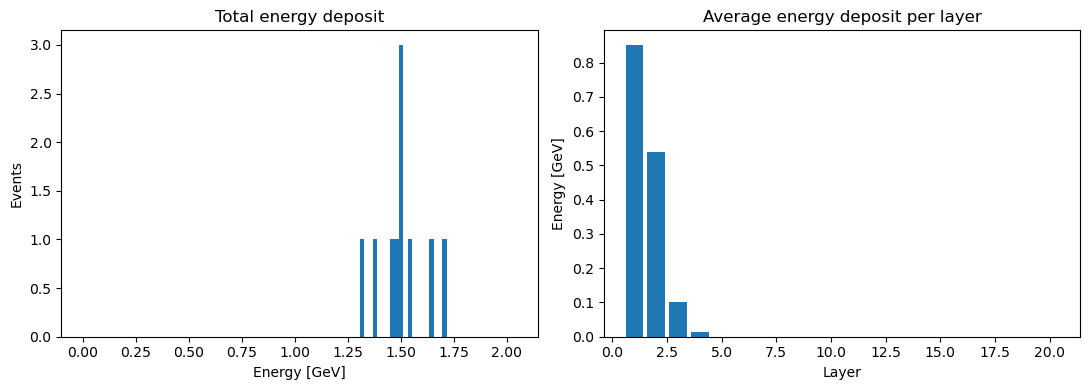

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].stairs(energy_counts, energy_edges, fill=True)
axes[0].set(xlabel="Energy [GeV]", ylabel="Events", title="Total energy deposit")
axes[1].bar(range(1, N_LAYERS + 1), average_layer_energy)
axes[1].set(xlabel="Layer", ylabel="Energy [GeV]", title="Average energy deposit per layer")
fig.tight_layout()

Most energetic layer: 1
Hottest cell: 98.5% of that layer's energy


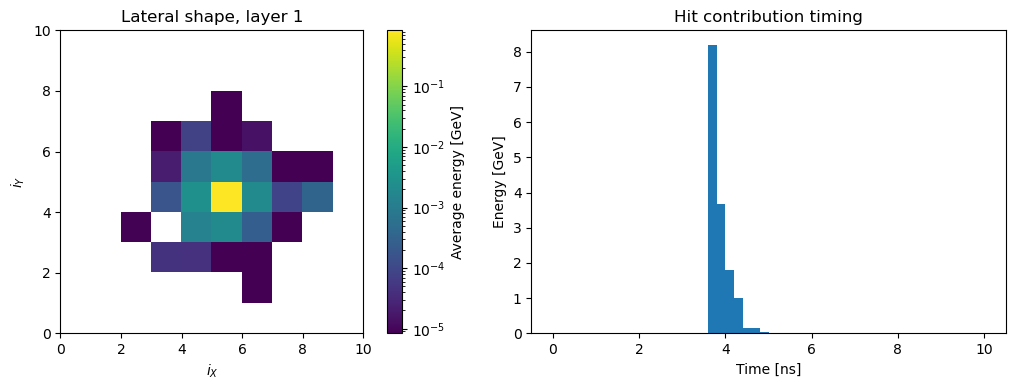

In [9]:
busiest = int(np.argmax(lateral_energy.sum(axis=(1, 2))))
lateral = lateral_energy[busiest]
print(f"Most energetic layer: {busiest + 1}")
print(f"Hottest cell: {100 * lateral.max() / lateral.sum():.1f}% of that layer's energy")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Brass has a Moliere radius of about 2 cm against 10 cm cells, so the impact
# cell takes almost everything. A log scale is what makes the tails visible.
image = axes[0].imshow(
    np.ma.masked_less_equal(lateral.T, 0), origin="lower",
    extent=(0, N_CELLS, 0, N_CELLS), aspect="equal",
    norm=LogNorm(vmin=lateral.max() * 1e-5, vmax=lateral.max()),
)
axes[0].set(xlabel=r"$i_X$", ylabel=r"$i_Y$", title=f"Lateral shape, layer {busiest + 1}")
fig.colorbar(image, ax=axes[0], label="Average energy [GeV]")
axes[1].stairs(time_energy, time_edges, fill=True)
axes[1].set(xlabel="Time [ns]", ylabel="Energy [GeV]", title="Hit contribution timing")
fig.tight_layout()

## Cross-check the cell indices

The hottest hit in the first event should have the same stored position as the cell centre implied by its decoded indices.

In [10]:
hottest = int(np.argmax(ak.to_numpy(hit_energies[0])))
sub = decoder.get(int(cell_ids[0][hottest]), "cellid")
i_x, i_y = sub % N_CELLS, sub // N_CELLS

# EDM4hep stores positions in mm (see the EDM4hep yaml file), so these are the
# XML dimensions CellX and SensLayerX / 2 expressed in mm.
CELL = 100.0  # mm
HALF = 500.0  # mm
implied_x = -HALF + CELL / 2 + i_x * CELL
implied_y = HALF - CELL / 2 - i_y * CELL
stored_x, stored_y = float(hit_x[0][hottest]), float(hit_y[0][hottest])

print(f"hottest cell: cellid={sub} -> iX={i_x}, iY={i_y}")
print(f"  implied centre : x={implied_x:+7.1f} mm, y={implied_y:+7.1f} mm")
print(f"  stored position: x={stored_x:+7.1f} mm, y={stored_y:+7.1f} mm")

if np.isclose(implied_x, stored_x) and np.isclose(implied_y, stored_y):
    print("  -> match: the cell indices are decoded correctly")
else:
    print("  -> MISMATCH: this input is not a simplecalo2 file carrying the")
    print("     cells placed in Hands-on 4. Check which file was opened above.")

hottest cell: cellid=45 -> iX=5, iY=4
  implied centre : x=  +50.0 mm, y=  +50.0 mm
  stored position: x=  +50.0 mm, y=  +50.0 mm
  -> match: the cell indices are decoded correctly
